# DEFINIÇÕES E CONSTANTES

In [1]:
# ---------- Paths ----------
PASTA_GERAL = "Dados/"
PASTA_DADOS = PASTA_GERAL + "Arquivos/"
SETUP_TESTES_XLSX = "Testes.xlsx"
NOME_ARQUIVO_LOG = "TEST_X.CSV"

REMOVER_SUPERDEPENDENCIA = True
# ---------- Pré-Processamento ----------
TEMPO_LIMPEZA_INICIAL = 5  # segundos
TIMESTAMP_PARA_SEGUNDOS = 1e3  # converter timestamp para segundos
NOME_VARIAVEL_TEMPO = "Timestamp"

# ---------- Estados ----------
niveis_estados = {
    0: "Balanceado",
    1: "Desbalanceado"
}

# HELPERS

In [2]:
def descritiva(df_, var, vresp='survived', max_classes=5):
    """
    Gera um gráfico descritivo da taxa de sobreviventes por categoria da variável especificada.
    
    Parâmetros:
    df : DataFrame - Base de dados a ser analisada.
    var : str - Nome da variável categórica a ser analisada.
    """
    # Limitar os valores em 2 casas decimais para variáveis numéricas
    df = df_.copy()
    df[var] = df[var].round(2)
    
    if df[var].nunique()>max_classes:
        df[var] = pd.qcut(df[var], max_classes, duplicates='drop')
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    sns.pointplot(data=df, y=vresp, x=var, ax=ax1)
    
    # Criar o segundo eixo y para a taxa de sobreviventes
    ax2 = ax1.twinx()

    sns.countplot(data=df, x=var, palette='viridis', alpha=0.5, ax=ax2)
    ax2.set_ylabel('Frequência', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    
    ax1.set_zorder(2)
    ax1.patch.set_visible(False)  # Tornar o fundo do eixo 1 transparente
    
    # Exibir o gráfico
    plt.show()
    
def relatorio_missing(df):
    print(f'Número de linhas: {df.shape[0]} | Número de colunas: {df.shape[1]}')
    return pd.DataFrame({'Pct_missing': df.isna().mean().apply(lambda x: f"{x:.1%}"),
                          'Freq_missing': df.isna().sum().apply(lambda x: f"{x:,.0f}").replace(',','.')})
    

# Importações de Biblioteca

In [3]:
import os
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import lightgbm as lgb
import shap
import joblib 

# from helpers import descritiva

c:\Users\Lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Carregar Arquivos

## Carregar Testes.xlsx

In [4]:
# ---------- 1) Ler metadados do Excel ----------
df_meta = pd.read_excel(os.path.join(PASTA_GERAL, "Testes.xlsx"))

# Normaliza nomes de colunas (caso venham com espaços/variações)
df_meta = df_meta.rename(columns={
    "ID TEST": "ID_TEST",
})

# Garante tipos
df_meta["ID_TEST"] = df_meta["ID_TEST"].astype(int)

# Cria um dicionário: id -> (vel, desb)
meta_map = (
    df_meta
    .set_index("ID_TEST")[["Velocity", "Imbalance"]]
    .to_dict(orient="index")
)



## Carregar os Dados

In [5]:
dados_original_separados = []  # Lista para armazenar os dados lidos
dados_original_juntos = []     # Lista para armazenar os dados combinados

# ---------- 1) Definindo local do arquivo ----------
padrao = re.compile(NOME_ARQUIVO_LOG.replace("X", r"(\d+)"), re.IGNORECASE)

# ---------- 2) Lendo arquivos CSV ----------
for nome_arquivo in os.listdir(PASTA_DADOS):
    correspondencia = padrao.match(nome_arquivo)
    if correspondencia:
        id_teste = int(correspondencia.group(1))
        caminho_arquivo = os.path.join(PASTA_DADOS, nome_arquivo)
        
        # Lê o arquivo CSV
        df_dados = pd.read_csv(caminho_arquivo)
        
        # Adiciona colunas de metadados
        if id_teste in meta_map:
            df_dados["Velocity"] = meta_map[id_teste]["Velocity"]
            df_dados["Imbalance"] = meta_map[id_teste]["Imbalance"]
            df_dados["ID_TEST"] = id_teste
            
            dados_original_separados.append(df_dados)
            
            print(f"Lido arquivo: {nome_arquivo} com ID_TEST {id_teste}")
        else:
            print(f"Metadados não encontrados para ID_TEST {id_teste}")
            
# ---------- 3) Junta tudo em um único DataFrame ----------
dados_original_juntos = pd.concat(dados_original_separados, ignore_index=True)

Lido arquivo: TEST_1.csv com ID_TEST 1
Lido arquivo: TEST_10.csv com ID_TEST 10
Lido arquivo: TEST_11.csv com ID_TEST 11
Lido arquivo: TEST_12.csv com ID_TEST 12
Lido arquivo: TEST_13.csv com ID_TEST 13
Lido arquivo: TEST_14.csv com ID_TEST 14
Lido arquivo: TEST_15.csv com ID_TEST 15
Lido arquivo: TEST_16.csv com ID_TEST 16
Lido arquivo: TEST_17.csv com ID_TEST 17
Lido arquivo: TEST_18.csv com ID_TEST 18
Lido arquivo: TEST_19.csv com ID_TEST 19
Lido arquivo: TEST_2.csv com ID_TEST 2
Lido arquivo: TEST_20.csv com ID_TEST 20
Lido arquivo: TEST_21.csv com ID_TEST 21
Lido arquivo: TEST_22.csv com ID_TEST 22
Lido arquivo: TEST_23.csv com ID_TEST 23
Lido arquivo: TEST_24.csv com ID_TEST 24
Lido arquivo: TEST_25.csv com ID_TEST 25
Lido arquivo: TEST_26.csv com ID_TEST 26
Lido arquivo: TEST_27.csv com ID_TEST 27
Lido arquivo: TEST_28.csv com ID_TEST 28
Lido arquivo: TEST_29.csv com ID_TEST 29
Lido arquivo: TEST_3.csv com ID_TEST 3
Lido arquivo: TEST_30.csv com ID_TEST 30
Lido arquivo: TEST_31.

### Checagem rápida dos dados

In [6]:
print(dados_original_juntos.head())
print(dados_original_juntos.columns)

   Timestamp  Accel_X  Accel_Y  Accel_Z  Gyro_X  Gyro_Y  Gyro_Z  Mag_X  Mag_Y  \
0          0      -48       36      996       0       0       0    214   -366   
1         10      -46       25     1005       0       0       0    213   -372   
2         20      -73       70      979       0       0       0    210   -372   
3         30      -56       56      988       0       0       0    213   -361   
4         40      -54       26      996       0       0       0    205   -366   

   Mag_Z  Velocity  Imbalance  ID_TEST  
0   -942         0          0        1  
1   -951         0          0        1  
2   -952         0          0        1  
3   -939         0          0        1  
4   -957         0          0        1  
Index(['Timestamp', 'Accel_X', 'Accel_Y', 'Accel_Z', 'Gyro_X', 'Gyro_Y',
       'Gyro_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'Velocity', 'Imbalance',
       'ID_TEST'],
      dtype='object')


# Pre Processing

## Limpeza inicial dos dados
Limpa os primeiros segundos de cada arquivo para não ter nenhum resquício de ruido, ou seja, em velocidade não ter ruido de movimento em parado ou aceleração.
 

In [7]:
# Limpar os primeiros segundos de cada teste carregado
for id_teste in dados_original_juntos["ID_TEST"].unique():
    filtro_teste = dados_original_juntos["ID_TEST"] == id_teste
    limite_tempo = (TEMPO_LIMPEZA_INICIAL) * TIMESTAMP_PARA_SEGUNDOS
    
    dados_original_juntos = dados_original_juntos[~(filtro_teste & (dados_original_juntos[NOME_VARIAVEL_TEMPO] < limite_tempo))]



## Remoção de colunas que não são utilizadas e separando entre treino e teste

In [ ]:
# Antes de remover, quero que o código separe dois grupos: Um onde vai conter os dados de balanceados onde Velocity = 30 e também os dados de desbaçanceado onde velocity = 60. Dai o outro grupo vai ser usado para treinar o modelo.
dados_teste = dados_original_juntos[
    ((dados_original_juntos["Velocity"] == 30) & (dados_original_juntos["Imbalance"] == 0)) |
    ((dados_original_juntos["Velocity"] == 60) & (dados_original_juntos["Imbalance"].isin([1, 2])))
].copy()

dados_treino = dados_original_juntos[
    ~(
        ((dados_original_juntos["Velocity"] == 30) & (dados_original_juntos["Imbalance"] == 0)) |
        ((dados_original_juntos["Velocity"] == 60) & (dados_original_juntos["Imbalance"].isin([1, 2])))
    )
].copy()
# Binarização do alvo
dados_treino["Imbalance"] = dados_treino["Imbalance"].apply(lambda x: 0 if x == 0 else 1)
dados_teste["Imbalance"] = dados_teste["Imbalance"].apply(lambda x: 0 if x == 0 else 1)
# Separação entre features e alvo
X_train = dados_treino.drop(columns=[NOME_VARIAVEL_TEMPO, "Velocity", "ID_TEST", "Imbalance"])
y_train = dados_treino["Imbalance"]

X_test = dados_teste.drop(columns=[NOME_VARIAVEL_TEMPO, "Velocity", "ID_TEST", "Imbalance"])
y_test = dados_teste["Imbalance"]

# Análise Geral

## Verifica possíveis missing

In [ ]:
relatorio_missing(dados_original_juntos)
relatorio_missing(dados_treino)
relatorio_missing(dados_teste)
relatorio_missing(X_train)
relatorio_missing(X_test)
print("Quantidade de dados em y_train:", y_train.shape[0])
print("Quantidade de dados em y_test:", y_test.shape[0])
 

## Verifica os tipos

In [ ]:
metadados = dados_original_juntos.dtypes
print(metadados)

## Análise descritiva

In [ ]:
# Análise descritiva básica

for variavel in dados_filtados.columns:
    print(f'\n\nAnálise univariada de {variavel}:')
    print(dados_filtados[variavel].describe())
    
    descritiva(dados_filtados, variavel, vresp='Imbalance', max_classes=5)

# Árvores de decisão

## LightGBM

### Configuração LightGBM

In [ ]:
# Treinamento do modelo LightGBM com otimização Bayesiana de hiperparâmetros
param_space = {
    'n_estimators': Integer(100, 700), #Número de árvores
    'max_depth': Integer(3, 15), #Profundidade máxima da árvore
    'learning_rate': Real(0.2, 0.3, prior='log-uniform'), #Taxa de aprendizado
    'num_leaves': Integer(20, 150), #Número de folhas
    'min_child_samples': Integer(5, 100), #Número mínimo de amostras em uma folha
    'subsample': Real(0.5, 1.0), #Subamostragem de dados
    'colsample_bytree': Real(0.5, 1.0), #Subamostragem de colunas(features)
    'reg_alpha': Real(1e-9, 10.0, prior='log-uniform'), #Regularização L1
    'reg_lambda': Real(1e-9, 10.0, prior='log-uniform'), #Regularização L2
    'boosting_type': Categorical(['gbdt', 'dart', 'goss']) #Tipo de boosting
}

#Configurar o modelo LightGBM
lgb_model = lgb.LGBMClassifier(random_state=2208, verbose=-1)

# Configurar o Bayesian Optimization
bayes_search = BayesSearchCV(
    estimator=lgb_model,
    search_spaces=param_space,
    n_iter=35,  # Número de iterações de otimização
    cv=3,  # Validação cruzada com 3 folds
    scoring='accuracy',  # Métrica de avaliação
    n_jobs=-1,  # Usar todos os núcleos disponíveis
    verbose=3,
    random_state=2208
)

### Execução Árvore

In [ ]:
# Execução do Bayesian Optimization
tempo_ini = pd.Timestamp.now() # Início do tempo
bayes_search.fit(X_train, y_train)
tempo_fim = pd.Timestamp.now() # Fim do tempo
print(f'Tempo de execução do Bayesian Optimization: {tempo_fim - tempo_ini}')

# Avaliação do modelo otimizado
print("Melhores hiperparâmetros encontrados:")
print(bayes_search.best_params_)

### Outros modelos

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

svm = SVC(kernel='rbf', probability=True)

svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
# Comparar a acurácia dos modelos
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Acurácia Random Forest: {accuracy_rf:.4f}")
print(f"Acurácia SVM: {accuracy_svm:.4f}")
print(f"Acurácia Logistic Regression: {accuracy_lr:.4f}")

### Carregar Árvore

In [ ]:
import joblib

# Carregar o estimator salvo (já treinado)
bayes_search_loaded = joblib.load('LightGBM_best_estimator.pkl')

### Previsões

In [ ]:
# Select model
if 'bayes_search' in locals():
    model = bayes_search.best_estimator_
    model_name = "bayes_search"
elif 'bayes_search_loaded' in locals():
    model = bayes_search_loaded
    model_name = "bayes_search_loaded"
else:
    raise ValueError("Nenhum modelo disponível para fazer previsões.")

# Prediction
pred = model.predict(X_test)
print(f"Usando {model_name} para previsões.")

# Print hyperparameters (CORRETO)
print("\nHiperparâmetros do modelo:")

params = model.get_params()

keys_of_interest = [
    "n_estimators",
    "max_depth",
    "learning_rate",
    "num_leaves",
    "min_child_samples"
]

for k in keys_of_interest:
    print(f"{k}: {params.get(k)}")

### Estatísticas da árvore gerada

In [ ]:

    
# Matriz de confusão e estatísticas de classificação
cm = confusion_matrix(y_test, pred)
print("Matriz de Confusão:")
print(cm)
print("\nRelatório de Classificação:")
print(classification_report(y_test, pred))
print(f'Accuracy: {accuracy_score(y_test, pred):.2%}')


In [ ]:
# Função personalizada para summary (multiClassSummary equivalente)
def multiCLassSummary(df, levels):
    report = classification_report(df['obs'], df['pred'], target_names=levels, output_dict=True)
    summary = { 
               'Accuracy': report['accuracy'],
    }
    for level in levels:
        summary[f'{level} Precision'] = report[level]['precision']
        summary[f'{level} Recall'] = report[level]['recall']
        summary[f'{level} F1-Score'] = report[level]['f1-score']
    return summary
# Gerar um DataFrame temporário para avaliar o modelo
lgb_aval = pd.DataFrame({
    'pred': pred,
    'obs': y_test
})

# Calcular e exibir o resumo personalizado
print(niveis_estados.values()   )
metrics_summary = pd.Series(multiCLassSummary(lgb_aval,niveis_estados.values()))
print("\nMétricas de Avaliação Personalizadas:")
print(metrics_summary)

# Mostrar como tabela ou gráfico para colocar no relatório
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Matriz de confusão como DataFrame
cm_df = pd.DataFrame(cm, index=niveis_estados.values(), columns=niveis_estados.values())
print("\nMatriz de Confusão como DataFrame:")
print(cm_df)
# Mostrar como tabela ou gráfico para colocar no relatório
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Matriz de confusão como DataFrame
cm_df = pd.DataFrame(cm, index=niveis_estados.values(), columns=niveis_estados.values())
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()  

### Análise Shap

In [ ]:
model = bayes_search.best_estimator_
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X) 

### Execução Árvore sem algumas variáveis

In [ ]:
# Execução da arvore sem algumas variáveis
removed_cols = ['Accel_Z', 'Accel_Y', 'Gyro_X','Gyro_Y']

X_removed_cols = dados_filtados.drop(columns=['Imbalance'] + removed_cols)
X_train_removed_cols, X_test_removed_cols, y_train_removed_cols, y_test_removed_cols = train_test_split(X_removed_cols, y, test_size=0.2, random_state=2208)

# Execução do Bayesian Optimization
tempo_ini = pd.Timestamp.now() # Início do tempo
bayes_search_with_removed_cols = bayes_search
bayes_search_with_removed_cols.fit(X_train_removed_cols, y_train_removed_cols)
tempo_fim = pd.Timestamp.now() # Fim do tempo
print(f'Tempo de execução do Bayesian Optimization: {tempo_fim - tempo_ini}')

# Avaliação do modelo otimizado
print("Melhores hiperparâmetros encontrados:")
print(bayes_search_with_removed_cols.best_params_)

In [ ]:
pred_with_removed_cols = bayes_search_with_removed_cols.predict(X_test_removed_cols)
print(X_removed_cols.columns)

# Matriz de confusão e estatísticas de classificação
cm = confusion_matrix(y_test_removed_cols, pred_with_removed_cols)
print("Matriz de Confusão:")
print(cm)
print("\nRelatório de Classificação:")
print(classification_report(y_test_removed_cols, pred_with_removed_cols))
print(f'Accuracy: {accuracy_score(y_test_removed_cols, pred_with_removed_cols):.2%}')

### Execução Árvore só com x

In [ ]:
# Execução da arvore sem algumas variáveis deixando apenas Accel_X
removed_cols = dados_filtados.columns.difference(['Accel_X']).tolist()

X_removed_cols_2 = dados_filtados.drop(columns=['Imbalance'] + removed_cols)
X_train_removed_cols_2, X_test_removed_cols_2, y_train_removed_cols_2, y_test_removed_cols_2 = train_test_split(X_removed_cols_2, y, test_size=0.2, random_state=2208)

# Execução do Bayesian Optimization
tempo_ini = pd.Timestamp.now() # Início do tempo
bayes_search_with_removed_cols_2 = bayes_search
bayes_search_with_removed_cols_2.fit(X_train_removed_cols_2, y_train_removed_cols_2)
tempo_fim = pd.Timestamp.now() # Fim do tempo
print(f'Tempo de execução do Bayesian Optimization: {tempo_fim - tempo_ini}')

# Avaliação do modelo otimizado
print("Melhores hiperparâmetros encontrados:")
print(bayes_search_with_removed_cols_2.best_params_)

In [ ]:
pred_with_removed_cols_2 = bayes_search_with_removed_cols_2.predict(X_test_removed_cols_2)
print(X_removed_cols_2.columns)

# Matriz de confusão e estatísticas de classificação
cm = confusion_matrix(y_test_removed_cols_2, pred_with_removed_cols_2)
print("Matriz de Confusão:")
print(cm)
print("\nRelatório de Classificação:")
print(classification_report(y_test_removed_cols_2, pred_with_removed_cols_2))
print(f'Accuracy: {accuracy_score(y_test_removed_cols_2, pred_with_removed_cols_2):.2%}')

## Salvar Árvore

In [ ]:
# Salvar o estimator otimizado (pickle)
joblib.dump(bayes_search.best_estimator_, 'LightGBM_best_estimator.pkl')

## Matriz de correlação

In [ ]:
# Fazer a matriz de correlação dos dados filtrados
corr = dados_filtados.corr()
plt.figure(figsize=(12, 10), dpi=1024)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlação dos Dados Filtrados', fontsize=16)
plt.tight_layout() # Ajusta o layout para evitar cortes de elementos
plt.tick_params(labelsize=10) # Ajusta o tamanho dos rótulos dos eixos
plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo x para melhor visualização
plt.show()

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=42)
import pandas as pd

mi = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    "feature": X.columns,
    "mutual_info": mi
}).sort_values("mutual_info", ascending=False)

mi_df


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(
    data=mi_df,
    x="mutual_info",
    y="feature",
    palette="viridis"
)
plt.title("Mutual Information por Feature")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.show()

# Diversos

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb


# =========================================================
# CONFIGURAÇÕES
# =========================================================
FS = 100                        # Taxa de amostragem atual

# =========================================================
# FUNÇÕES DE FEATURES
# =========================================================
def extract_time_features(signal: np.ndarray) -> dict:
    signal = np.asarray(signal, dtype=float)

    rms = np.sqrt(np.mean(signal ** 2))
    abs_signal = np.abs(signal)
    peak = np.max(abs_signal)

    return {
        "mean": np.mean(signal),
        "std": np.std(signal),
        "rms": rms,
        "max": np.max(signal),
        "min": np.min(signal),
        "peak_to_peak": np.max(signal) - np.min(signal),
        "kurtosis": kurtosis(signal, fisher=True, bias=False),
        "skewness": skew(signal, bias=False),
        "abs_mean": np.mean(abs_signal),
        "crest_factor": peak / rms if rms != 0 else 0.0,
    }

def create_windows(signal, window_size=100, step=100):
    windows = []
    n = len(signal)

    for start in range(0, n - window_size + 1, step):
        end = start + window_size
        windows.append(signal[start:end])

    return windows

def build_feature_table_windowed(df, signal_columns, fs=100, window_size=100):
    all_rows = []

    for test_id, group in df.groupby("ID_TEST"):
        rows = extract_features_windowed(group, signal_columns, fs, window_size)
        all_rows.extend(rows)

    return pd.DataFrame(all_rows)

def extract_features_windowed(group, signal_columns, fs=100, window_size=100):
    rows = []

    # cria janelas baseadas no primeiro eixo
    base_signal = group[signal_columns[0]].values
    windows_idx = create_windows(base_signal, window_size)

    for i in range(len(windows_idx)):
        row = {}

        for col in signal_columns:
            signal = group[col].values
            window = signal[i * window_size:(i + 1) * window_size]

            feats = extract_features(window, fs)

            for k, v in feats.items():
                row[f"{col}_{k}"] = v

        # metadados
        row["ID_TEST"] = group["ID_TEST"].iloc[0]
        row["Velocity"] = group["Velocity"].iloc[0]
        row["Imbalance"] = group["Imbalance"].iloc[0]

        rows.append(row)

    return rows

def extract_freq_features(signal: np.ndarray, fs: float = 100.0) -> dict:
    signal = np.asarray(signal, dtype=float)

    n = len(signal)
    if n == 0:
        return {
            "dominant_freq": 0.0,
            "dominant_amp": 0.0,
            "spectral_energy": 0.0,
            "low_freq_energy": 0.0,
            "mid_freq_energy": 0.0,
            "high_freq_energy": 0.0,
            "spectral_centroid": 0.0,
        }

    # Remover média ajuda na FFT
    signal = signal - np.mean(signal)

    fft_vals = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    mag = np.abs(fft_vals)

    if len(mag) > 0:
        mag[0] = 0.0  # remover DC

    dom_idx = int(np.argmax(mag)) if len(mag) > 0 else 0
    spectral_energy = np.sum(mag ** 2)

    low_mask = freqs < 10
    mid_mask = (freqs >= 10) & (freqs < 30)
    high_mask = freqs >= 30

    mag_sum = np.sum(mag)
    spectral_centroid = np.sum(freqs * mag) / mag_sum if mag_sum > 0 else 0.0

    return {
        "dominant_freq": freqs[dom_idx] if len(freqs) > 0 else 0.0,
        "dominant_amp": mag[dom_idx] if len(mag) > 0 else 0.0,
        "spectral_energy": spectral_energy,
        "low_freq_energy": np.sum(mag[low_mask] ** 2),
        "mid_freq_energy": np.sum(mag[mid_mask] ** 2),
        "high_freq_energy": np.sum(mag[high_mask] ** 2),
        "spectral_centroid": spectral_centroid,
    }


def extract_features(signal: np.ndarray, fs: float = 100.0) -> dict:
    features = {}
    features.update(extract_time_features(signal))
    features.update(extract_freq_features(signal, fs))
    return features


def extract_multi_axis_features(group: pd.DataFrame, signal_columns: list[str], fs: float = 100.0) -> dict:
    features = {}

    for col in signal_columns:
        signal = group[col].values
        axis_features = extract_features(signal, fs)

        for feat_name, feat_value in axis_features.items():
            features[f"{col}_{feat_name}"] = feat_value

    return features


# =========================================================
# CONSTRUÇÃO DA TABELA DE FEATURES
# =========================================================
def build_feature_table(df: pd.DataFrame, signal_columns: list[str], fs: float = 100.0) -> pd.DataFrame:
    rows = []

    for test_id, group in df.groupby("ID_TEST"):
        row = {
            "ID_TEST": test_id,
            "Velocity": group["Velocity"].iloc[0],
            "Imbalance": group["Imbalance"].iloc[0],
        }

        row.update(extract_multi_axis_features(group, signal_columns, fs))
        rows.append(row)

    return pd.DataFrame(rows)


# =========================================================
# DIAGNÓSTICO
# =========================================================
def print_basic_checks(df: pd.DataFrame, name: str) -> None:
    print(f"\n===== {name} =====")
    print(df.head())
    print("\nShape:", df.shape)
    print("\nColunas:")
    print(df.columns.tolist())


def print_split_diagnostics(dados_treino: pd.DataFrame, dados_teste: pd.DataFrame) -> None:
    print("\n===== COMBINAÇÕES NO TREINO =====")
    print(
        dados_treino[["Velocity", "Imbalance"]]
        .drop_duplicates()
        .sort_values(["Velocity", "Imbalance"])
        .reset_index(drop=True)
    )

    print("\n===== COMBINAÇÕES NO TESTE =====")
    print(
        dados_teste[["Velocity", "Imbalance"]]
        .drop_duplicates()
        .sort_values(["Velocity", "Imbalance"])
        .reset_index(drop=True)
    )

    print("\n===== DISTRIBUIÇÃO y_train =====")
    print(dados_treino["Imbalance"].value_counts().sort_index())

    print("\n===== DISTRIBUIÇÃO y_test =====")
    print(dados_teste["Imbalance"].value_counts().sort_index())


def evaluate_model(model_name: str, y_true: pd.Series, y_pred: np.ndarray) -> None:
    print(f"\n{'=' * 50}")
    print(f"MODELO: {model_name}")
    print(f"{'=' * 50}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("\nMatriz de Confusão:")
    print(confusion_matrix(y_true, y_pred))
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred, digits=4))


# =========================================================
# PROGRAMA PRINCIPAL
# =========================================================

# -----------------------------------------------------
# 3) Construir feature table
# -----------------------------------------------------
# 1. Gerar tabela de features
feature_table = build_feature_table_windowed(
    df=dados_original_juntos,
    signal_columns=["Accel_X", "Accel_Y", "Accel_Z", "Gyro_X", "Gyro_Y", "Gyro_Z", "Mag_X", "Mag_Y", "Mag_Z"],
    fs=100,
    window_size=100
)

# 2. Ver resultado
print(feature_table.head())
print(feature_table.shape)

print_basic_checks(feature_table, "FEATURE TABLE")

# -----------------------------------------------------
# 4) Binarizar alvo
# 0 = balanceado
# 1 = desbalanceado (1 ou 2)
# -----------------------------------------------------
feature_table["Imbalance"] = feature_table["Imbalance"].apply(lambda x: 0 if x == 0 else 1)

# -----------------------------------------------------
# 5) Split do jeito que você definiu
# Teste:
#   - Velocity = 30 e Imbalance = 0
#   - Velocity = 60 e Imbalance = 1
# Como binarizamos, o antigo 2 também virou 1.
# -----------------------------------------------------
dados_teste = feature_table[
    ((feature_table["Velocity"] == 30) & (feature_table["Imbalance"] == 0)) |
    ((feature_table["Velocity"] == 60) & (feature_table["Imbalance"] == 1))
].copy()

dados_treino = feature_table.drop(index=dados_teste.index).copy()

print_split_diagnostics(dados_treino, dados_teste)


# -----------------------------------------------------
# 6) Separar X e y
# -----------------------------------------------------

if REMOVER_SUPERDEPENDENCIA:

    # =====================================================
    # 1) Separar X e y
    # =====================================================
    # calcular MI só com features de treino é mais correto
    X_base = dados_treino.drop(columns=["ID_TEST", "Velocity", "Imbalance"]).copy()
    y_base = dados_treino["Imbalance"].copy()

    # =====================================================
    # 2) Informação mútua
    # =====================================================
    X_mi = X_base.copy().fillna(X_base.mean())

    mi = mutual_info_classif(X_mi, y_base, random_state=42)

    mi_df = pd.DataFrame({
        'Feature': X_base.columns,
        'Mutual_Information': mi
    }).sort_values(by='Mutual_Information', ascending=False)

    # =====================================================
    # 3) Remover features correlacionadas
    # =====================================================
    features_sorted = mi_df["Feature"].tolist()
    selected = []

    for feat in features_sorted:
        if all(abs(X_mi[feat].corr(X_mi[s])) < 0.99 for s in selected):
            selected.append(feat)

    n_original = X_base.shape[1]
    n_final = len(selected)
    perc_reducao = 100 * (1 - n_final / n_original)

    print(f"Features originais: {n_original}")
    print(f"Features após remoção: {n_final}")
    print(f"Redução: {perc_reducao:.2f}%")

    # =====================================================
    # 4) Aplicar no treino/teste
    # =====================================================
    # agora aplica no treino e no teste
    X_train = dados_treino.drop(columns=["ID_TEST", "Velocity", "Imbalance"])[selected].copy()
    X_test  = dados_teste.drop(columns=["ID_TEST", "Velocity", "Imbalance"])[selected].copy()

    y_train = dados_treino["Imbalance"].copy()
    y_test  = dados_teste["Imbalance"].copy()

else:

    # Sem remoção de correlação
    X_train = dados_treino.drop(columns=["ID_TEST", "Velocity", "Imbalance"])
    X_test  = dados_teste.drop(columns=["ID_TEST", "Velocity", "Imbalance"])

    y_train = dados_treino["Imbalance"].copy()
    y_test  = dados_teste["Imbalance"].copy()

print("\n===== CHECK FINAL =====")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)
print("Mesmas colunas em treino/teste?", X_train.columns.tolist() == X_test.columns.tolist())
print("Velocity em X_train?", "Velocity" in X_train.columns)
print("Imbalance em X_train?", "Imbalance" in X_train.columns)

    

   Accel_X_mean  Accel_X_std  Accel_X_rms  Accel_X_max  Accel_X_min  \
0        -40.89     1.574135    40.920288        -36.0        -44.0   
1        -40.94     1.508774    40.967792        -38.0        -45.0   
2        -40.77     1.370073    40.793014        -38.0        -44.0   
3        -41.01     1.486573    41.036935        -38.0        -45.0   
4        -40.67     1.612793    40.701966        -37.0        -45.0   

   Accel_X_peak_to_peak  Accel_X_kurtosis  Accel_X_skewness  Accel_X_abs_mean  \
0                   8.0          0.107503          0.252737             40.89   
1                   7.0         -0.070505         -0.369503             40.94   
2                   6.0         -0.618611          0.001040             40.77   
3                   7.0         -0.295923         -0.168033             41.01   
4                   8.0         -0.358964         -0.247111             40.67   

   Accel_X_crest_factor  ...  Mag_Z_dominant_freq  Mag_Z_dominant_amp  \
0            

In [ ]:
# Análise descritiva básica

vars_escolhidas = [
    'Mag_X_max',
    'Gyro_X_mean',
    'Accel_X_low_freq_energy'
]

for variavel in vars_escolhidas:
    print(f'\nAnálise univariada de {variavel}:')
    print(feature_table[variavel].describe())
    descritiva(feature_table, variavel, vresp='Imbalance', max_classes=4)
# -----------------------------------------------------

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

# Copiar base
df_mi = feature_table.copy()
df_mi = feature_table.dropna()

X = df_mi.drop(columns=['Imbalance', 'ID_TEST', 'Velocity'])
y = df_mi['Imbalance']

# Calcular informação mútua
mi = mutual_info_classif(X, y, random_state=42)

# Organizar em DataFrame
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Information': mi
}).sort_values(by='Mutual_Information', ascending=False)

# Mostrar ranking
print(mi_df)

# Plotar
plt.figure(figsize=(10, 8))
sns.barplot(data=mi_df.head(20), x='Mutual_Information', y='Feature')
plt.title('Top 20 features por Informação Mútua com Imbalance')
plt.xlabel('Informação Mútua')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Selecionar as Top 20 features
top_features = mi_df['Feature'].head(20).tolist()

# Subset do dataset
df_top = feature_table[top_features]

# Calcular correlação
corr_matrix = df_top.corr()

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0
)

plt.title('Matriz de Correlação - Top 20 Features (Informação Mútua)')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# Separar X e y
X = feature_table.drop(columns=['Imbalance'])
X = X.fillna(X.mean())
y = feature_table['Imbalance']

# Calcular MI
mi = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Information': mi
}).sort_values(by='Mutual_Information', ascending=False)

# Número original
n_original = X.shape[1]

# Ordenar features por MI
features_sorted = mi_df['Feature'].tolist()

selected = []

for feat in features_sorted:
    if all(abs(X[feat].corr(X[s])) < 0.99 for s in selected):
        selected.append(feat)

# Dataset reduzido
X_reduced = X[selected]

# Estatísticas
n_final = len(selected)
perc = (n_final / n_original) * 100

print(f"Features originais: {n_original}")
print(f"Features após remoção: {n_final}")
print(f"Redução: {100 - perc:.2f}%")

In [ ]:
# -----------------------------------------------------
# 7) Random Forest
# -----------------------------------------------------
rf = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    )
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))


# -----------------------------------------------------
# 8) SVM
# -----------------------------------------------------
svm = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    SVC(kernel="rbf", probability=True, random_state=42)
)

svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("\n=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, digits=4))


# -----------------------------------------------------
# 9) Logistic Regression
# -----------------------------------------------------
lr = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, digits=4))


# -----------------------------------------------------
# Importância das features - Logistic Regression
# -----------------------------------------------------
coef = lr.named_steps["logisticregression"].coef_[0]
features = X_train.columns

importance = pd.Series(coef, index=features).sort_values(key=np.abs, ascending=False)

print("\n=== TOP 20 FEATURES MAIS IMPORTANTES - Logistic Regression ===")
print(importance.head(20))


# -----------------------------------------------------
# Ajuste de threshold - Logistic Regression
# -----------------------------------------------------
y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_pred_lr_thr = (y_prob_lr >= 0.4).astype(int)

print("\n=== Logistic Regression com threshold = 0.4 ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_thr))
print(confusion_matrix(y_test, y_pred_lr_thr))
print(classification_report(y_test, y_pred_lr_thr, digits=4))


# -----------------------------------------------------
# Logistic Regression TOP 20
# -----------------------------------------------------
top_features = importance.head(20).index.tolist()

X_train_top = X_train[top_features].copy()
X_test_top = X_test[top_features].copy()

lr_top = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)

lr_top.fit(X_train_top, y_train)

y_prob_top = lr_top.predict_proba(X_test_top)[:, 1]
y_pred_top = (y_prob_top >= 0.4).astype(int)

print("\n=== Logistic Regression TOP 20 + threshold = 0.4 ===")
print("Accuracy:", accuracy_score(y_test, y_pred_top))
print(confusion_matrix(y_test, y_pred_top))
print(classification_report(y_test, y_pred_top, digits=4))


# -----------------------------------------------------
# 10) LightGBM
# -----------------------------------------------------
lgb_model = make_pipeline(
    SimpleImputer(strategy="median"),
    lgb.LGBMClassifier(
        random_state=2208,
        verbose=-1,
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
    )
)

lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

print("\n=== LightGBM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print(confusion_matrix(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb, digits=4))

In [ ]:
top10_features = importance.head(10).index.tolist()

corr_matrix = X_train[top10_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Matriz de correlação das 10 variáveis mais relevantes")
plt.tight_layout()
plt.show()

In [ ]:
top_var_features = X_train.var().sort_values(ascending=False).head(30).index.tolist()

corr_matrix = X_train[top_var_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Matriz de correlação das 30 variáveis de maior variância")
plt.tight_layout()
plt.show()

In [ ]:
mi = mutual_info_classif(X_train, y_train, random_state=42)

mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)

print("Top 20 variáveis por informação mútua:")
print(mi_series.head(20))

In [ ]:
plt.figure(figsize=(10, 8))
mi_series.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 variáveis por informação mútua")
plt.xlabel("Informação mútua")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

In [ ]:
top_lr = importance.head(20).sort_values()

plt.figure(figsize=(10, 8))
top_lr.plot(kind="barh")
plt.title("Top 20 variáveis mais importantes - Regressão Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

# =========================
# 1) Correlação - top 20 LR
# =========================
top20_features = importance.head(20).index.tolist()
corr_matrix = X_train[top20_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Matriz de correlação das 20 variáveis mais relevantes")
plt.tight_layout()
plt.savefig("correlacao_top20.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 2) Informação mútua
# =========================
mi = mutual_info_classif(X_train, y_train, random_state=42)
mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)

print("Top 20 variáveis por informação mútua:")
print(mi_series.head(20))

plt.figure(figsize=(10, 8))
mi_series.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 variáveis por informação mútua")
plt.xlabel("Informação mútua")
plt.ylabel("Variável")
plt.tight_layout()
plt.savefig("mutual_information_top20.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 3) Importância LR
# =========================
print("Top 20 features mais importantes - Regressão Logística")
print(importance.head(20))

top_lr = importance.head(20).sort_values()

plt.figure(figsize=(10, 8))
top_lr.plot(kind="barh")
plt.title("Top 20 variáveis mais importantes - Regressão Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.tight_layout()
plt.savefig("importance_logistic_top20.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 4) Comparação de modelos
# =========================
plt.figure(figsize=(8, 5))
plt.bar(results["Modelo"], results["Accuracy"])
plt.title("Comparação de acurácia entre os modelos")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("comparacao_modelos.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# =========================
# 1) Selecionar só features de aceleração
# =========================
accel_features = [col for col in X_train.columns if col.startswith("Accel_")]
mag_features = [col for col in X_train.columns if col.startswith("Mag_")]
gyro_features = [col for col in X_train.columns if col.startswith("Gyro_")]

print(f"Total de features de aceleração: {len(accel_features)}")
print(f"Total de features de magnetômetro: {len(mag_features)}")
print(f"Total de features de giroscópio: {len(gyro_features)}")

X_train_accel = X_train[accel_features].copy()
X_test_accel = X_test[accel_features].copy()
X_train_mag = X_train[mag_features].copy()
X_test_mag = X_test[mag_features].copy()
X_train_gyro = X_train[gyro_features].copy()
X_test_gyro = X_test[gyro_features].copy()


# =========================
# 2) Treinar modelo
# =========================
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_accel = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)
lr_mag = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)
lr_gyro = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)

lr_accel.fit(X_train_accel, y_train)
lr_mag.fit(X_train_mag, y_train)
lr_gyro.fit(X_train_gyro, y_train)

# =========================
# 3) Predição com threshold ajustado
# =========================
y_prob_accel = lr_accel.predict_proba(X_test_accel)[:, 1]
y_pred_accel = (y_prob_accel >= 0.4).astype(int)

y_prob_mag = lr_mag.predict_proba(X_test_mag)[:, 1]
y_pred_mag = (y_prob_mag >= 0.4).astype(int)

y_prob_gyro = lr_gyro.predict_proba(X_test_gyro)[:, 1]
y_pred_gyro = (y_prob_gyro >= 0.4).astype(int)

# =========================
# 4) Avaliação
# =========================
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\n=== Logistic Regression (somente acelerômetro) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_accel))
print(confusion_matrix(y_test, y_pred_accel))
print(classification_report(y_test, y_pred_accel, digits=4))
print("\nComparação:")
print(f"Só acelerômetro: {accuracy_score(y_test, y_pred_accel):.4f}")
print(f"Só magnetômetro: {accuracy_score(y_test, y_pred_mag):.4f}")
print(f"Só giroscópio: {accuracy_score(y_test, y_pred_gyro):.4f}")

Total de features de aceleração: 45
Total de features de magnetômetro: 43
Total de features de giroscópio: 38

=== Logistic Regression (somente acelerômetro) ===
Accuracy: 0.937037037037037
[[ 87   3]
 [ 14 166]]
              precision    recall  f1-score   support

           0     0.8614    0.9667    0.9110        90
           1     0.9822    0.9222    0.9513       180

    accuracy                         0.9370       270
   macro avg     0.9218    0.9444    0.9311       270
weighted avg     0.9420    0.9370    0.9379       270


Comparação:
Só acelerômetro: 0.9370
Só magnetômetro: 0.7222
Só giroscópio: 0.4481


In [10]:
# =========================
# 1) Selecionar apenas features do acelerômetro
# =========================
X_train_accel = X_train[accel_features].copy()
X_test_accel = X_test[accel_features].copy()

# =========================
# 2) Treinar Logistic só com acelerômetro
# =========================
lr_accel = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)

lr_accel.fit(X_train_accel, y_train)

# =========================
# 3) Importância das features (coeficientes)
# =========================
coef_accel = lr_accel.named_steps["logisticregression"].coef_[0]

importance_accel = (
    pd.Series(coef_accel, index=X_train_accel.columns)
    .sort_values(key=np.abs, ascending=False)
)

print("\n=== TOP 20 FEATURES (ACELERÔMETRO) ===")
print(importance_accel.head(20))

# =========================
# 4) Selecionar TOP 20 do acelerômetro
# =========================
top20_accel = importance_accel.head(20).index.tolist()

X_train_top20_accel = X_train_accel[top20_accel].copy()
X_test_top20_accel = X_test_accel[top20_accel].copy()

# =========================
# 5) Treinar modelo reduzido
# =========================
lr_top20_accel = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)

lr_top20_accel.fit(X_train_top20_accel, y_train)

# =========================
# 6) Predição (threshold = 0.4)
# =========================
y_prob_top20_accel = lr_top20_accel.predict_proba(X_test_top20_accel)[:, 1]
y_pred_top20_accel = (y_prob_top20_accel >= 0.4).astype(int)

# =========================
# 7) Avaliação
# =========================
print("\n=== Logistic Regression (TOP 20 ACELERÔMETRO) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_top20_accel))
print(confusion_matrix(y_test, y_pred_top20_accel))
print(classification_report(y_test, y_pred_top20_accel, digits=4))


=== TOP 20 FEATURES (ACELERÔMETRO) ===
Accel_X_rms                  3.295109
Accel_Z_mean                -2.850413
Accel_X_low_freq_energy      2.028529
Accel_Y_mid_freq_energy     -1.738743
Accel_X_high_freq_energy    -1.655214
Accel_X_mean                 1.627639
Accel_Z_rms                 -1.620048
Accel_Y_spectral_centroid   -1.537210
Accel_X_max                  1.319846
Accel_X_std                  1.283582
Accel_Y_spectral_energy     -1.212653
Accel_Y_low_freq_energy      1.168348
Accel_Y_kurtosis             1.118187
Accel_X_mid_freq_energy      1.048078
Accel_Z_spectral_centroid    0.994433
Accel_X_spectral_centroid   -0.849884
Accel_X_min                  0.840774
Accel_Y_max                 -0.806242
Accel_Y_crest_factor        -0.762951
Accel_Y_std                 -0.750225
dtype: float64

=== Logistic Regression (TOP 20 ACELERÔMETRO) ===
Accuracy: 0.9444444444444444
[[ 88   2]
 [ 13 167]]
              precision    recall  f1-score   support

           0     0.8713    

In [ ]:
model = lr_top20_accel.named_steps["logisticregression"]
scaler = lr_top20_accel.named_steps["standardscaler"]

coef = model.coef_[0]
intercept = model.intercept_[0]
means = scaler.mean_
scales = scaler.scale_
features = X_train_top20_accel.columns.tolist()

for f, c, m, s in zip(features, coef, means, scales):
    print(f"{f}: coef={c}, mean={m}, scale={s}")

print("Intercept:", intercept)
print("Threshold:", 0.4)

Accel_X_rms: coef=3.2866572777055527, mean=183.2079517556183, scale=128.85728825947376
Accel_Z_mean: coef=-2.501064340969367, mean=995.0225185185184, scale=13.013823104883999
Accel_X_low_freq_energy: coef=2.3898647345102937, mean=22080282.3156545, scale=30552861.509327397
Accel_Y_mid_freq_energy: coef=-2.326503228602426, mean=267452942.4766822, scale=505161225.14815843
Accel_X_high_freq_energy: coef=-2.3586704783394787, mean=31394468.494634748, scale=44863747.80412135
Accel_X_mean: coef=0.9593726515170604, mean=113.36337962962963, scale=146.19351040393772
Accel_Z_rms: coef=-1.9589379811421141, mean=1009.7350198070255, scale=30.702023961068353
Accel_Y_spectral_centroid: coef=-1.4552660880464585, mean=26.941517140028324, scale=2.4426079251584105
Accel_X_max: coef=1.447644930888607, mean=330.80925925925925, scale=330.59153871480385
Accel_X_std: coef=1.6617034445313776, mean=93.56356739226915, scale=84.80221020485612
Accel_Y_spectral_energy: coef=-1.6104164566477643, mean=723049349.7574074

20


c:\Users\Lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


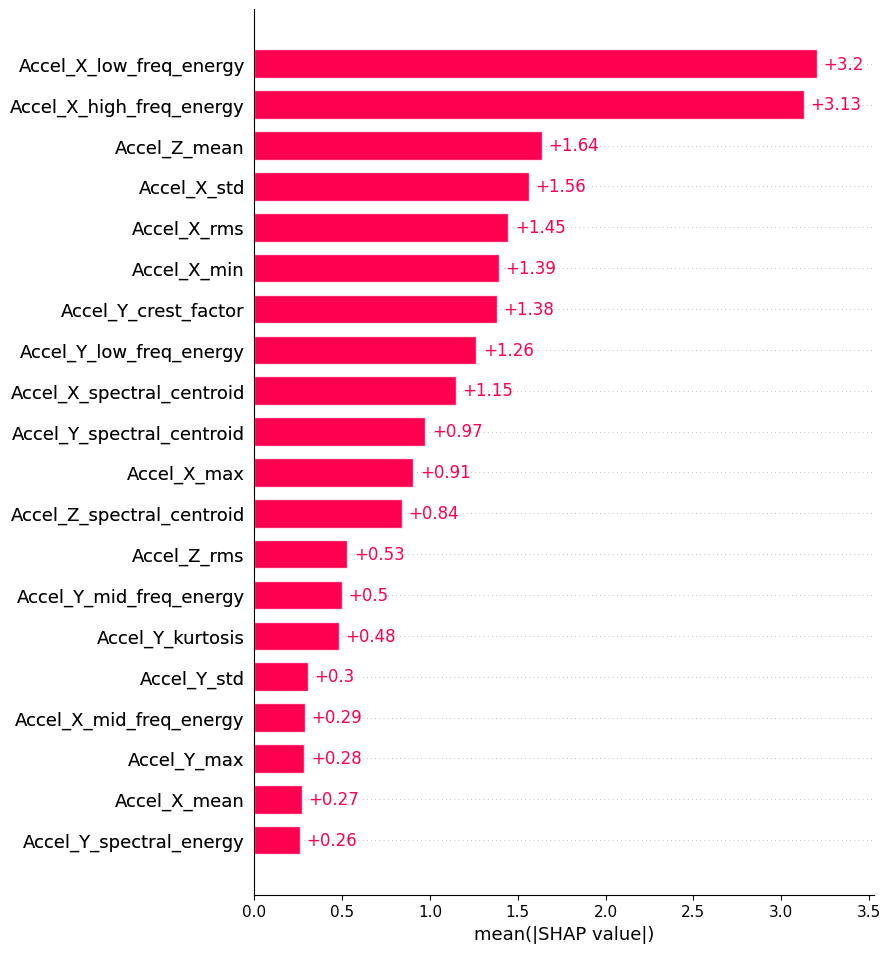

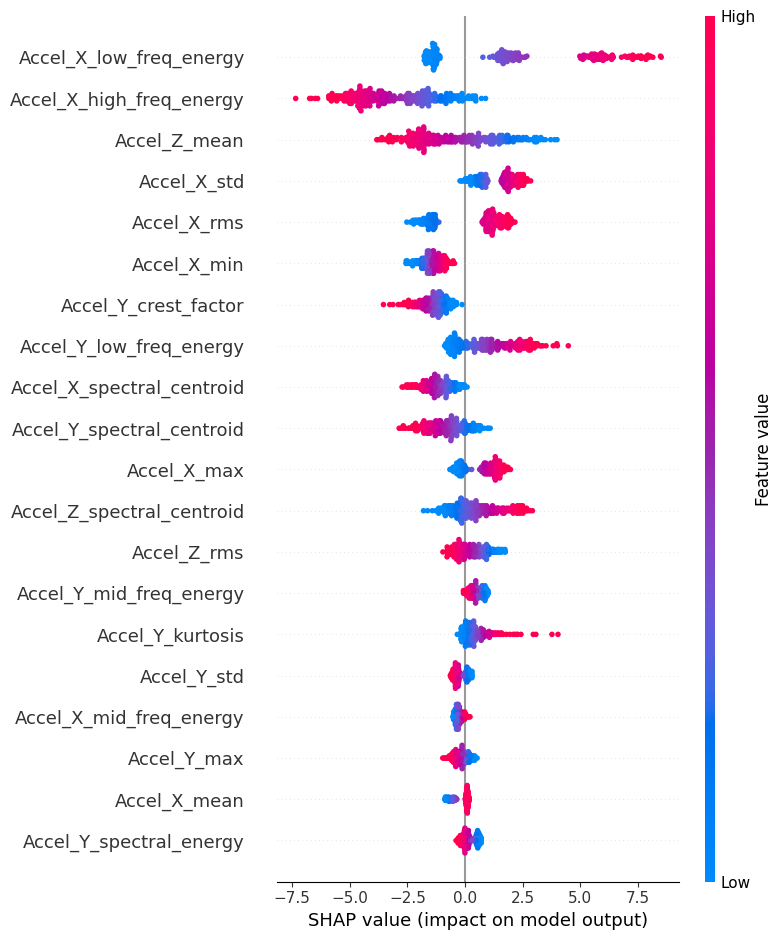

                      Feature  MeanAbsSHAP
2     Accel_X_low_freq_energy     3.203595
4    Accel_X_high_freq_energy     3.130240
1                Accel_Z_mean     1.636272
9                 Accel_X_std     1.561317
0                 Accel_X_rms     1.445243
16                Accel_X_min     1.390656
18       Accel_Y_crest_factor     1.381809
11    Accel_Y_low_freq_energy     1.262867
15  Accel_X_spectral_centroid     1.148720
7   Accel_Y_spectral_centroid     0.973736
8                 Accel_X_max     0.905734
14  Accel_Z_spectral_centroid     0.837800
6                 Accel_Z_rms     0.528943
3     Accel_Y_mid_freq_energy     0.498658
12           Accel_Y_kurtosis     0.480067
19                Accel_Y_std     0.304277
13    Accel_X_mid_freq_energy     0.286817
17                Accel_Y_max     0.284710
5                Accel_X_mean     0.269063
10    Accel_Y_spectral_energy     0.257386
Matriz de confusão:
[[ 88   2]
 [ 13 167]]

Relatório de classificação:
              precision  

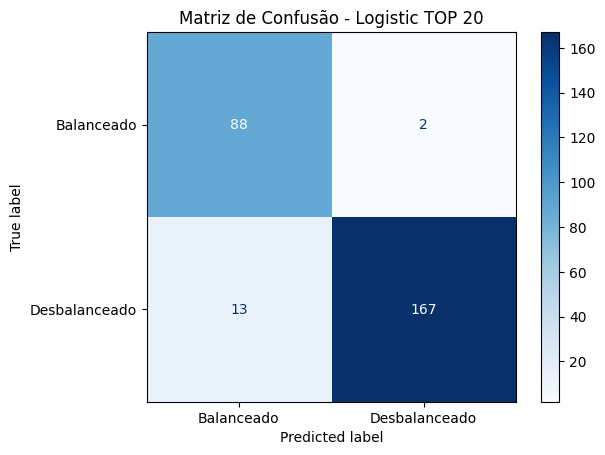

TN = 88
FP = 2
FN = 13
TP = 167


In [16]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
top_features = [
    'Accel_X_rms',
    'Accel_Z_mean',
    'Accel_X_low_freq_energy',
    'Accel_Y_mid_freq_energy',
    'Accel_X_high_freq_energy',
    'Accel_X_mean',
    'Accel_Z_rms',
    'Accel_Y_spectral_centroid',
    'Accel_X_max',
    'Accel_X_std',
    'Accel_Y_spectral_energy',
    'Accel_Y_low_freq_energy',
    'Accel_Y_kurtosis',
    'Accel_X_mid_freq_energy',
    'Accel_Z_spectral_centroid',
    'Accel_X_spectral_centroid',
    'Accel_X_min',
    'Accel_Y_max',    
    'Accel_Y_crest_factor',
    'Accel_Y_std'
]
print(len(top_features))


X_train_top = X_train[top_features].copy()
X_test_top = X_test[top_features].copy()

# =========================
# 2) Treinar modelo TOP 20
# =========================
lr_top = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)

lr_top.fit(X_train_top, y_train)

# =========================
# 3) Aplicar preprocessamento separadamente
# =========================
imputer = lr_top.named_steps["simpleimputer"]
scaler = lr_top.named_steps["standardscaler"]
model = lr_top.named_steps["logisticregression"]

X_train_top_imp = pd.DataFrame(
    imputer.transform(X_train_top),
    columns=X_train_top.columns,
    index=X_train_top.index
)

X_test_top_imp = pd.DataFrame(
    imputer.transform(X_test_top),
    columns=X_test_top.columns,
    index=X_test_top.index
)

X_train_top_scaled = pd.DataFrame(
    scaler.transform(X_train_top_imp),
    columns=X_train_top.columns,
    index=X_train_top.index
)

X_test_top_scaled = pd.DataFrame(
    scaler.transform(X_test_top_imp),
    columns=X_test_top.columns,
    index=X_test_top.index
)

# =========================
# 4) SHAP para Logistic Regression
# =========================
explainer = shap.LinearExplainer(model, X_train_top_scaled)
shap_values = explainer(X_test_top_scaled)

# =========================
# 5) Gráfico de importância global
# =========================
shap.plots.bar(shap_values, max_display=20)

# =========================
# 6) Gráfico summary
# =========================
shap.summary_plot(shap_values.values, X_test_top_scaled, feature_names=X_test_top_scaled.columns)

# =========================
# 7) Salvar média absoluta do SHAP em tabela
# =========================
shap_importance = pd.DataFrame({
    "Feature": X_test_top_scaled.columns,
    "MeanAbsSHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("MeanAbsSHAP", ascending=False)

print(shap_importance)
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =========================
# 1) Predição
# =========================
y_prob_top = lr_top.predict_proba(X_test_top)[:, 1]
y_pred_top = (y_prob_top >= 0.4).astype(int)

# =========================
# 2) Matriz de confusão
# =========================
cm = confusion_matrix(y_test, y_pred_top)
print("Matriz de confusão:")
print(cm)

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_top, digits=4))

# =========================
# 3) Plot
# =========================
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Balanceado", "Desbalanceado"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão - Logistic TOP 20")
plt.show()

# =========================
# 4) Extrair elementos
# =========================
tn, fp, fn, tp = cm.ravel()

print(f"TN = {tn}")  # balanceado corretamente classificado
print(f"FP = {fp}")  # falso alarme
print(f"FN = {fn}")  # falha não detectada
print(f"TP = {tp}")  # desbalanceado corretamente detectado